In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import (
    MinMaxScaler,
    RobustScaler,
    PowerTransformer,
    StandardScaler,
)
from mlpforecast.data.transform import DatasetObjective
from mlpforecast.forecaster.conformal import MLPGAMCRForecast
from IPython.display import clear_output
from aquarel import load_theme
import matplotlib.pyplot as plt
import arviz as az
az.style.use(["science", "arviz-doc", "tableau-colorblind10"])
import matplotlib
nice_fonts = {
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "axes.labelsize": 8,
    "font.size": 8,
    "legend.fontsize": 8,
    "legend.frameon": False,
}
matplotlib.rcParams.update(nice_fonts)
import matplotlib_inline.backend_inline

matplotlib_inline.backend_inline.set_matplotlib_formats(
    "svg", "pdf", "retina"
)  # For expor

## Load dataset
We first load and preprocess Albania load demand data available in this  [here](https://data.dtu.dk/articles/dataset/Albanian_national_electricity_consumption_and_weather_conditions_for_2016-2019/22786922). 


In [2]:
data = pd.read_parquet("../data/albania_res.parquet")
data.index = pd.to_datetime(data.index, utc="UTC")

In [3]:

common_params = {
    "target_series": ["NetLoad"],
    "unknown_features": [],
    "calendar_variables": ["HOUR", "Session"],
    "known_calendar_features": ["HOUR-cosin", "Session-cosin"],
    "known_continuous_features": ["NetLoad_lag_48", "NetLoad_lag_336", "Temperature"],
    "input_window_size": 96,
    "forecast_horizon": 48,
}
data_params = {
    "input_scaler": PowerTransformer('yeo-johnson'),
    "target_scaler": StandardScaler(),
    "lags": [1, 7],
    "windows": [],
    "window_funcs": ["mean"],
    "period": "30min",
    "date_column": "timestamp",
}

We update the parameters and define the  ``DatasetObjective``. This line ```data_params.update(common_params)`` merges common_params into data_params, ensuring all relevant settings are included for the dataset transformation.

In [4]:
data_params.update(common_params)
ds = DatasetObjective(**data_params)
clear_output()

In [28]:


model_hparams = {
    "data_pipeline": ds,
    "embedding_size": 20,
    "embedding_type": None,
    "combination_type": "addition-comb",
    "hidden_size": 256,
    "num_layers": 2,
    "expansion_factor": 2,
    "residual": True,
    "activation_function": "SiLU",
    "out_activation_function": "Identity",
    "dropout_rate": 0.2,
    "alpha": 0.3,
    'lambda_lasso':1e-3,
    'normal_sigma':True,
    'sign_res':False,
    'residual':False,
    "max_epochs": 20,
}
model_hparams.update(common_params)
model = MLPGAMCRForecast(
    exp_name="test-crf-normal", 
    model_type="MLPFCRFCP", 
    hparams=model_hparams, 
    rich_progress_bar=False,
    max_epochs=20
)

## Training the Model

To train the model, use the following code:

```python
model.fit()
````

In [29]:
model.fit(data.reset_index()[:20000])
clear_output()

To make predictions, use the following code:


In [24]:
pred=model.predict(data.reset_index()[20000 : 20000 + 48 * 7 * 2], daily_feature=True)
_, ground_th=model.get_ground_truth(data.reset_index()[20000 : 20000 + 48 * 7 * 2], daily_feature=True)

Processing sequences: 100%|██████████| 5/5 [00:00<00:00, 95760.37it/s]


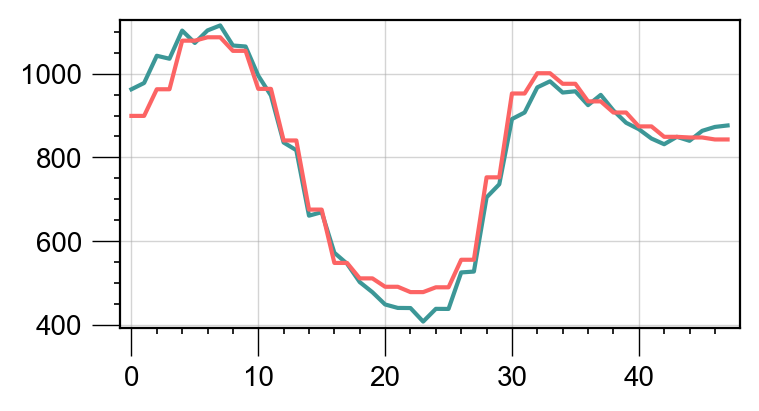

In [30]:
with load_theme("boxy_light"):
    fig, ax = plt.subplots(1, 1, figsize=(4, 2))
    ax.plot(pred['loc'][0, :, 0])
    ax.plot(ground_th[0, :, 0])
plt.show()

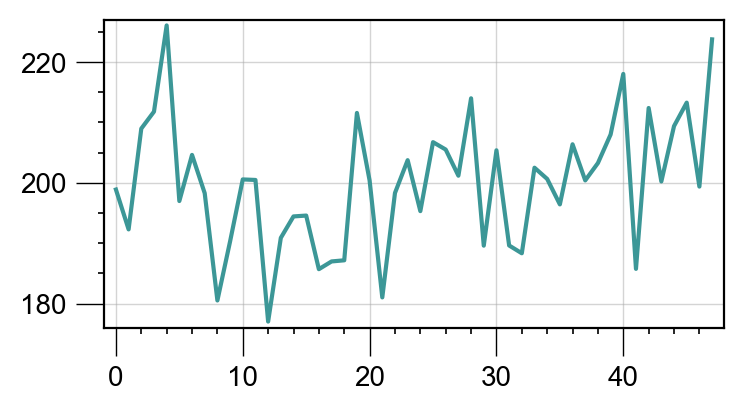

In [31]:
with load_theme("boxy_light"):
    fig, ax = plt.subplots(1, 1, figsize=(4, 2))
    ax.plot(pred['scale'][0, :, 0])
plt.show()

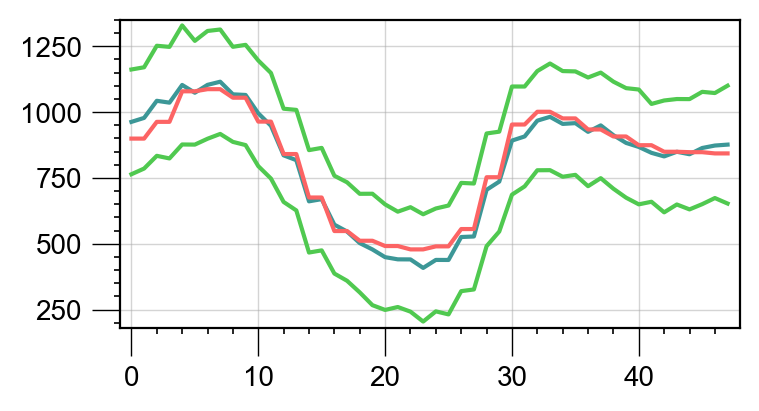

In [32]:
with load_theme("boxy_light"):
    fig, ax = plt.subplots(1, 1, figsize=(4, 2))
    ax.plot(pred['loc'][0, :, 0])
    ax.plot(ground_th[0, :, 0])
    ax.plot(pred['loc'][0, :, 0]+pred['scale'][0, :, 0], 'C2')
    ax.plot(pred['loc'][0, :, 0]-pred['scale'][0, :, 0], 'C2')
plt.show()

In [33]:
model.calibrate(calibrate_df=data.reset_index()[20000 : 20000 + 48 * 7 * 8])

In [34]:
pred=model.predict(data.reset_index()[20000 : 20000 + 48 * 7 * 2], daily_feature=True)

Processing sequences: 100%|██████████| 5/5 [00:00<00:00, 28728.11it/s]


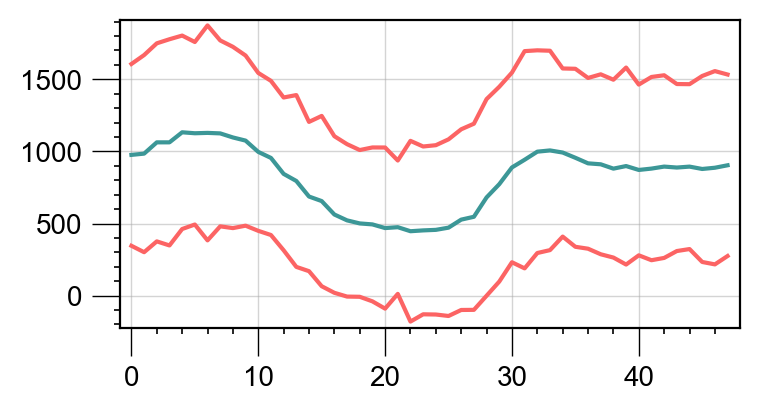

In [35]:
with load_theme("boxy_light"):
    fig, ax = plt.subplots(1, 1, figsize=(4, 2))
    ax.plot(pred['loc'][0, :, 0])
    ax.plot(pred['upper-calib'][0, :, 0]+pred['scale'][0, :, 0], 'C1')
    ax.plot(pred['lower-calib'][0, :, 0]-pred['scale'][0, :, 0], 'C1')
plt.show()